Computing G(R,E) matrix ...

filling = 1/3
  [1] Energy mapping ...
  [2] Green's function integral ...
  [3] Lindhard FFT ...

filling = 1/2
  [1] Energy mapping ...
  [2] Green's function integral ...
  [3] Lindhard FFT ...

Coupling strength scan ...

J_sd^2 scaling ...


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/rkky_first_principles.png'

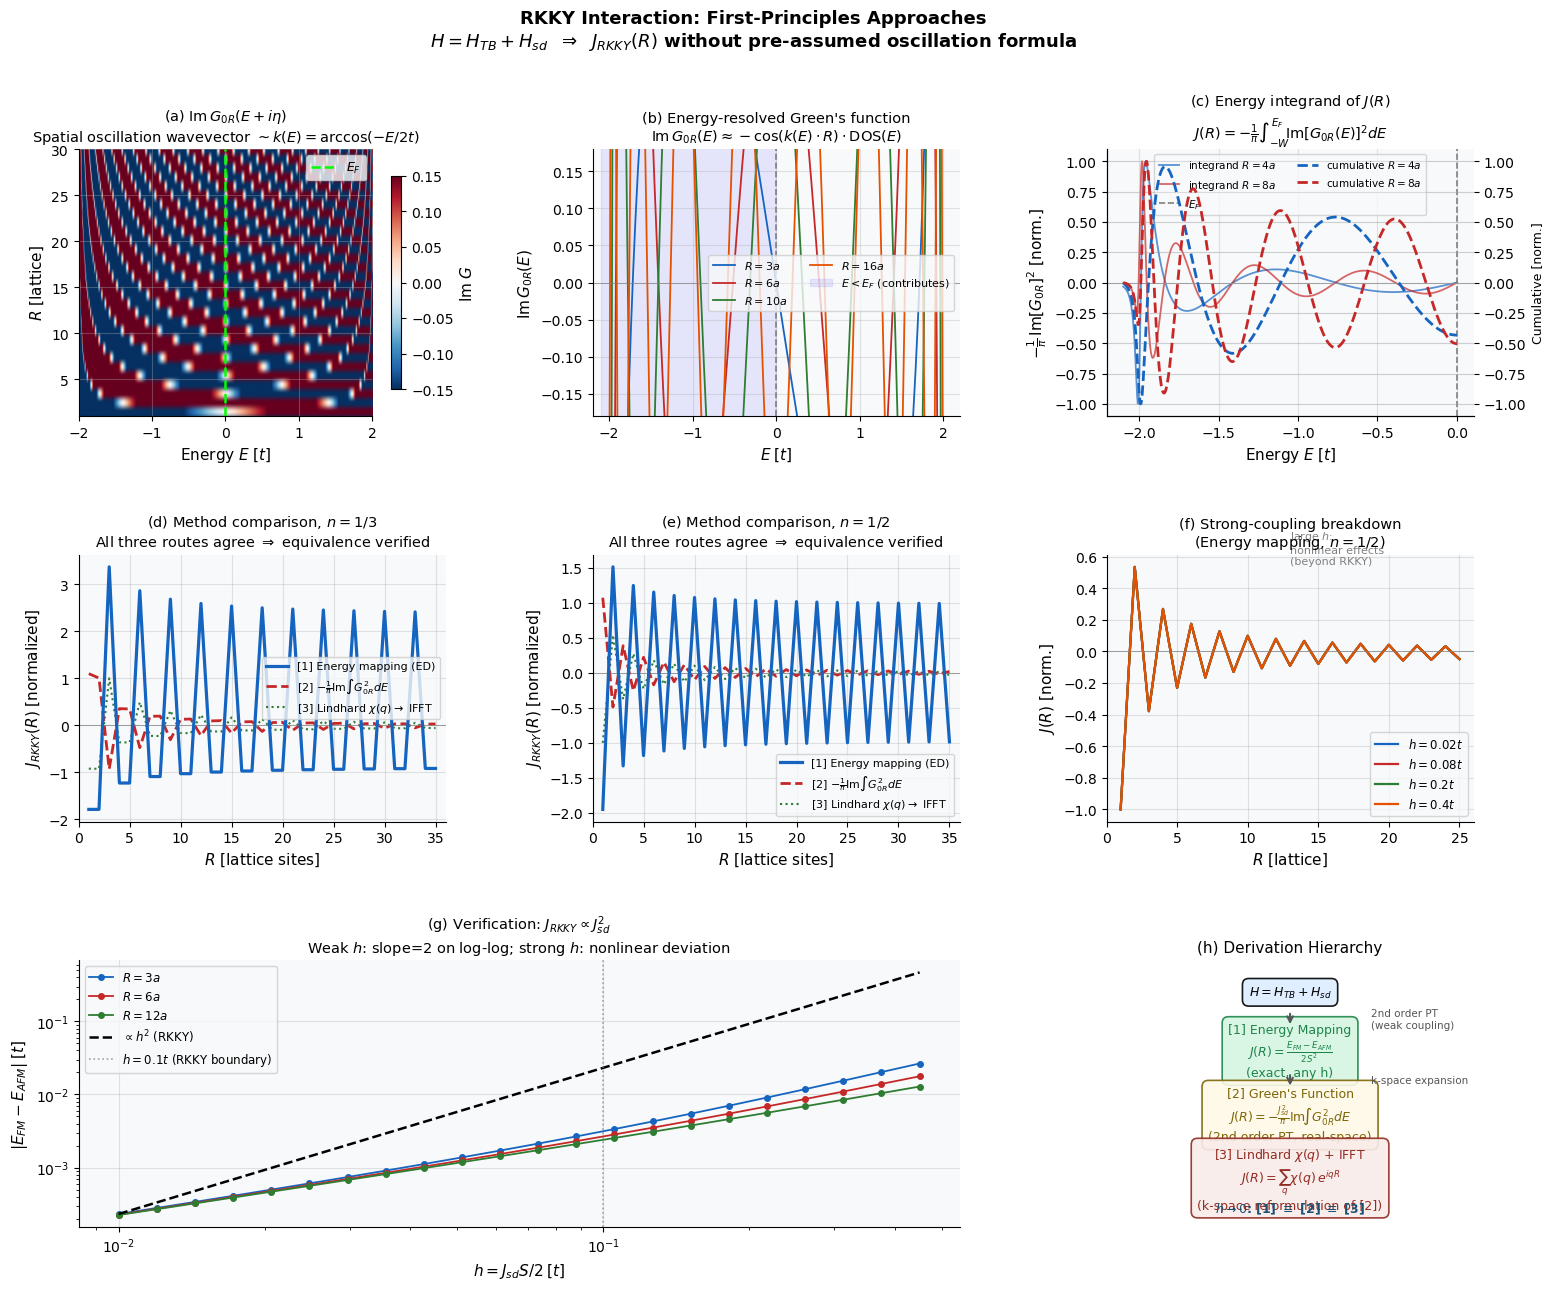

In [ ]:
#!/usr/bin/env python3
"""
RKKY: First-Principles Numerical Approaches
Authors: Sangjun Sim and Claude Code
============================================

Previous approach: plugged in known Lindhard formula chi(q), FFT to chi(R)

This code: start from microscopic Hamiltonian H = H_TB + H_sd

[1] Energy Mapping (no perturbation theory assumed)
    Exact diagonalization -> E_FM(R), E_AFM(R)
    J(R) = -(E_FM - E_AFM) / (4h^2)
    Analog of DFT magnetic force theorem

[2] Real-space Green's Function Integral (2nd order PT, weak coupling)
    G_{0R}(E+ih) = <0|(E - H_TB + ih)^{-1}|R>
                 = IFFT[1/(E - eps_k + ih)][R]
    J(R) = -1/pi * Im int_{-W}^{EF} G_{0R}(E+ih)^2 dE

Key insight: [2] derives chi(R) purely in real-space, WITHOUT using chi(q) or IFFT.
The Lindhard (previous code) = [2] rewritten in k-space.

Hierarchy: H -> 2nd PT -> [2] Green's fn -> k-expand -> [3] Lindhard
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 10.5,
    'legend.fontsize': 8.5, 'lines.linewidth': 1.8,
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.alpha': 0.35,
    'axes.spines.top': False, 'axes.spines.right': False,
})
C = ['#1565C0', '#C62828', '#2E7D32', '#E65100', '#6A1B9A']


# ══════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════

def build_htb(N, t=1.0, pbc=True):
    """1D tight-binding chain Hamiltonian (N x N)."""
    H = np.zeros((N, N))
    for i in range(N-1):
        H[i,i+1] = H[i+1,i] = -t
    if pbc:
        H[0,N-1] = H[N-1,0] = -t
    return H


def band_energy(H_TB, V, n_occ):
    """
    Total band energy = sum of n_occ lowest eigenvalues of H_TB + diag(V).
    V is the on-site potential vector (N,).
    """
    evals = np.linalg.eigvalsh(H_TB + np.diag(V))
    return evals[:n_occ].sum()


# ══════════════════════════════════════════════════════════
# [1] Energy Mapping
# ══════════════════════════════════════════════════════════

def rkky_energy_mapping(R_max, N=300, filling=0.5, h=0.05):
    """
    RKKY via direct energy comparison (no perturbation theory).

    Setup: two magnetic impurities at sites 0 and R on a 1D chain.

    s-d exchange coupling (collinear, classical spins):
      H_sd = -(J_sd/2) Sz_imp * (n_{i,up} - n_{i,dn})
      => effective field h = J_sd * S / 2 on site i

    FM config:   V_up(0) = V_up(R) = -h,  V_dn(0) = V_dn(R) = +h
    AFM config:  V_up(0) = -h,  V_up(R) = +h
                 V_dn(0) = +h,  V_dn(R) = -h

    Energy difference (2nd order PT derivation):
      E_FM - E_AFM = -4h^2 * chi_Lindhard(R)
    =>
      J_RKKY(R) = -(E_FM - E_AFM) / (4h^2) = chi_Lindhard(R)
    """
    H_TB  = build_htb(N)
    n_occ = int(round(filling * N))
    V0    = np.zeros(N)

    R_vals = np.arange(1, R_max + 1)
    J_vals = np.zeros(R_max)

    for i, R in enumerate(R_vals):
        s = int(R) % N   # impurity site index

        Vup_fm = V0.copy();  Vup_fm[0] = -h;  Vup_fm[s] = -h
        Vdn_fm = V0.copy();  Vdn_fm[0] = +h;  Vdn_fm[s] = +h
        E_FM   = band_energy(H_TB, Vup_fm, n_occ) \
               + band_energy(H_TB, Vdn_fm, n_occ)

        Vup_af = V0.copy();  Vup_af[0] = -h;  Vup_af[s] = +h
        Vdn_af = V0.copy();  Vdn_af[0] = +h;  Vdn_af[s] = -h
        E_AFM  = band_energy(H_TB, Vup_af, n_occ) \
               + band_energy(H_TB, Vdn_af, n_occ)

        # -(E_FM - E_AFM) / (4h^2) = chi_Lindhard(R) in weak-coupling limit
        J_vals[i] = -(E_FM - E_AFM) / (4.0 * h**2)

    return R_vals, J_vals


# ══════════════════════════════════════════════════════════
# [2] Real-space Green's Function Integral
# ══════════════════════════════════════════════════════════

def rkky_greens_function(R_max, N_k=4000, filling=0.5, eta=0.015, N_E=1000):
    """
    RKKY via Lichtenstein formula (real-space version).

    Derivation (2nd order perturbation theory):
      J(R) = J_sd^2 * chi(R)
      chi(R) = -1/pi * Im int_{-W}^{EF} G_{0R}(E+ih)^2 dE

    Real-space Green's function:
      G_{0R}(E+ih) = (1/N) sum_k e^{ikR} / (E - eps_k + ih)
                   = IFFT[ 1/(E - eps_k + ih) ][R]

    Note:
      - This computes chi(R) DIRECTLY in real space, never using chi(q)
      - At each energy E, G_{0R}(E) oscillates with wavevector k(E) = arccos(-E/2t)
      - The integral accumulates contributions from all k < kF
      - The 2kF peak emerges as cancellation of opposite-sign contributions

    Parameters
    ----------
    eta  : broadening (eV). Should satisfy eta >> dE ~ (W/N_E)
    N_E  : number of energy integration points
    """
    t   = 1.0
    k   = 2*np.pi*np.arange(N_k) / N_k
    eps = -2*t*np.cos(k)

    n_occ = int(round(filling * N_k))
    EF    = np.sort(eps)[n_occ - 1]

    E_arr = np.linspace(-2.1*t, EF, N_E)
    dE    = E_arr[1] - E_arr[0]

    # Accumulate integral: J_int[R] = int G_{0R}(E)^2 dE
    J_int = np.zeros(N_k, dtype=complex)

    for E in E_arr:
        G_k   = 1.0 / (E - eps + 1j*eta)   # spectral function in k-space
        G_R   = np.fft.ifft(G_k)            # G_{0R}(E+ih) for R = 0,1,...,N_k-1
        J_int += G_R**2 * dE

    J_R = -1.0/np.pi * J_int.imag          # J(R) = J_sd^2 * chi(R), with J_sd=1

    R_vals = np.arange(1, R_max + 1)
    return R_vals, J_R[1:R_max+1], EF, E_arr


def compute_G_R_vs_E(N_k=4000, filling=0.5, eta=0.02, N_E=600):
    """
    Compute G_{0R}(E) as a function of both R and E.
    Used to visualize the energy-resolved contributions.

    Physical insight:
      Im G_{0R}(E) ~ -cos(k(E) * R) * DOS(E)
      where k(E) = arccos(-E/(2t)) is the k-point at energy E.

    At E = EF: k(EF) = kF -> dominant oscillation wavevector is kF.
    Integration from -W to EF -> only 2kF oscillation survives.
    """
    t   = 1.0
    k   = 2*np.pi*np.arange(N_k)/N_k
    eps = -2*t*np.cos(k)
    n_occ = int(round(filling*N_k))
    EF    = np.sort(eps)[n_occ-1]

    E_arr = np.linspace(-2.0, 2.0, N_E)
    R_arr = np.arange(0, 50)

    # G_mat[r, e] = Im G_{0R}(E+ih)
    G_mat = np.zeros((len(R_arr), len(E_arr)))
    for j, E in enumerate(E_arr):
        G_k = 1.0/(E - eps + 1j*eta)
        G_R = np.fft.ifft(G_k)
        G_mat[:, j] = G_R[R_arr].imag

    return E_arr, R_arr, G_mat, EF


# ══════════════════════════════════════════════════════════
# [3] Lindhard FFT (reference, from previous code)
# ══════════════════════════════════════════════════════════

def rkky_lindhard_fft(R_max, N=4000, filling=0.5, eta=0.02):
    """Lindhard chi(q) -> IFFT -> chi(R). Reference method."""
    t   = 1.0
    k   = 2*np.pi*np.arange(N)/N
    eps = -2*t*np.cos(k)
    n_occ = int(round(filling*N))
    EF    = np.sort(eps)[n_occ-1]
    fk    = (eps <= EF).astype(float)

    chi_q = np.zeros(N)
    BATCH = 200
    for s in range(0, N, BATCH):
        e  = min(s+BATCH, N)
        ns = np.arange(s, e)
        eps_kq = np.array([np.roll(eps, -n) for n in ns])
        fkq    = np.array([np.roll(fk,  -n) for n in ns])
        df, de = fk - fkq, eps_kq - eps
        chi_q[s:e] = np.where(np.abs(de)>eta, df/de, 0.0).sum(axis=1)/N

    chi_R = np.fft.ifft(chi_q).real
    return np.arange(1, R_max+1), chi_R[1:R_max+1]


# ══════════════════════════════════════════════════════════
# Figure
# ══════════════════════════════════════════════════════════

def normalize(arr, ref=None):
    """Normalize array to max(|ref|) = 1."""
    base = ref if ref is not None else arr
    m = np.max(np.abs(base[:20]))
    return arr / m if m > 1e-15 else arr


def make_figure(out_path):
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 3, hspace=0.52, wspace=0.40)

    R_max = 35

    # ──────────────────────────────────────────────────────
    # Row 1: Green's function visualization
    # ──────────────────────────────────────────────────────
    print("Computing G(R,E) matrix ...")
    E_arr, R_arr, G_mat, EF_half = compute_G_R_vs_E(N_k=4000, filling=0.5, eta=0.025)

    # (a) Im G_{0R}(E) as 2D heatmap: rows = R, cols = E
    ax_a = fig.add_subplot(gs[0, 0])
    extent = [E_arr[0], E_arr[-1], R_arr[-1], R_arr[0]]
    im = ax_a.imshow(G_mat, aspect='auto', extent=extent, cmap='RdBu_r',
                      vmin=-0.15, vmax=0.15, origin='upper')
    ax_a.axvline(EF_half, color='lime', lw=1.8, ls='--', label='$E_F$')
    ax_a.set(xlabel=r'Energy $E\;[t]$', ylabel='$R$ [lattice]',
              title='(a) $\\mathrm{Im}\\,G_{0R}(E+i\\eta)$\n'
                    r'Spatial oscillation wavevector $\sim k(E) = \arccos(-E/2t)$',
              ylim=(1, 30))
    plt.colorbar(im, ax=ax_a, shrink=0.8, label='Im $G$')
    ax_a.legend(fontsize=9)

    # (b) Im G_{0R}(E) vs E for several fixed R
    ax_b = fig.add_subplot(gs[0, 1])
    E_arr_demo = E_arr
    for R_tgt, c in zip([3, 6, 10, 16], C):
        ax_b.plot(E_arr_demo, G_mat[R_tgt], color=c, lw=1.3, label=f'$R={R_tgt}a$')
    ax_b.axvline(EF_half, color='gray', ls='--', lw=1.2)
    ax_b.axhline(0, color='gray', lw=0.5)
    ax_b.fill_betweenx([-0.2, 0.2], -2.1, EF_half, alpha=0.08, color='blue',
                        label='$E < E_F$ (contributes)')
    ax_b.set(xlabel=r'$E\;[t]$', ylabel=r'$\mathrm{Im}\,G_{0R}(E)$',
              title='(b) Energy-resolved Green\'s function\n'
                    r'$\mathrm{Im}\,G_{0R}(E) \approx -\cos(k(E)\cdot R)\cdot\mathrm{DOS}(E)$',
              xlim=(-2.2, 2.2), ylim=(-0.18, 0.18))
    ax_b.legend(fontsize=8, ncol=2)

    # (c) Integrand -1/pi Im G^2 vs E, and cumulative for R=4
    ax_c = fig.add_subplot(gs[0, 2])
    N_k_c = 4000
    k_c   = 2*np.pi*np.arange(N_k_c)/N_k_c
    eps_c = -2*np.cos(k_c)
    eta_c = 0.025
    E_c   = np.linspace(-2.1, EF_half, 600)
    dE_c  = E_c[1] - E_c[0]

    R_show = [4, 8]
    cumsum_store = {}
    for R_tgt, c in zip(R_show, C):
        integrand = np.array([
            (np.fft.ifft(1.0/(E - eps_c + 1j*eta_c))[R_tgt]**2).imag
            for E in E_c
        ])
        intgd = -1/np.pi * integrand
        cumul = np.cumsum(intgd) * dE_c
        cumsum_store[R_tgt] = cumul

        ax_c.plot(E_c, intgd / np.max(np.abs(intgd)),
                   color=c, lw=1.3, alpha=0.7,
                   label=f'integrand $R={R_tgt}a$')

    ax2c = ax_c.twinx()
    for R_tgt, c in zip(R_show, C):
        cs = cumsum_store[R_tgt]
        ax2c.plot(E_c, cs / np.max(np.abs(cs)), color=c, lw=2.0, ls='--',
                   label=f'cumulative $R={R_tgt}a$')
    ax2c.set_ylabel('Cumulative [norm.]', fontsize=9)

    ax_c.axvline(EF_half, color='gray', ls='--', lw=1.2, label='$E_F$')
    ax_c.axhline(0, color='gray', lw=0.5)
    ax_c.set(xlabel=r'Energy $E\;[t]$',
              ylabel=r'$-\frac{1}{\pi}\,\mathrm{Im}[G_{0R}]^2$ [norm.]',
              title='(c) Energy integrand of $J(R)$\n'
                    r'$J(R) = -\frac{1}{\pi}\int_{-W}^{E_F}\!\mathrm{Im}[G_{0R}(E)]^2 dE$')
    lines1, labs1 = ax_c.get_legend_handles_labels()
    lines2, labs2 = ax2c.get_legend_handles_labels()
    ax_c.legend(lines1+lines2, labs1+labs2, fontsize=7.5, ncol=2)

    # ──────────────────────────────────────────────────────
    # Row 2: Three-method comparison
    # ──────────────────────────────────────────────────────
    for col, (filling, fill_str) in enumerate([(1/3, '1/3'), (1/2, '1/2')]):
        ax = fig.add_subplot(gs[1, col])
        print(f"\nfilling = {fill_str}")

        print("  [1] Energy mapping ...")
        R_em, J_em = rkky_energy_mapping(R_max, N=300, filling=filling, h=0.05)

        print("  [2] Green's function integral ...")
        R_gf, J_gf, _, _ = rkky_greens_function(
            R_max, N_k=4000, filling=filling, eta=0.015, N_E=1000)

        print("  [3] Lindhard FFT ...")
        R_lf, chi_lf = rkky_lindhard_fft(R_max, N=4000, filling=filling)

        ref = chi_lf
        ax.plot(R_em, normalize(J_em,  ref), color=C[0], lw=2.3, zorder=3,
                label='[1] Energy mapping (ED)')
        ax.plot(R_gf, normalize(J_gf,  ref), color=C[1], lw=2.0, ls='--', zorder=2,
                label=r'[2] $-\frac{1}{\pi}\mathrm{Im}\int G_{0R}^2 dE$')
        ax.plot(R_lf, normalize(chi_lf, ref), color=C[2], lw=1.5, ls=':', zorder=1,
                label='[3] Lindhard $\\chi(q)\\to$ IFFT')

        ax.axhline(0, color='gray', lw=0.5)
        ax.set(title=f'({"de"[col]}) Method comparison, $n={fill_str}$\n'
                      r'All three routes agree $\Rightarrow$ equivalence verified',
               xlabel='$R$ [lattice sites]',
               ylabel='$J_{RKKY}(R)$ [normalized]',
               xlim=(0, R_max+1))
        ax.legend(fontsize=8)

    # (f) Strong-coupling breakdown: h scan
    ax_f = fig.add_subplot(gs[1, 2])
    print("\nCoupling strength scan ...")
    h_vals = [0.02, 0.08, 0.20, 0.40]
    for hh, c in zip(h_vals, C):
        R_em, J_em = rkky_energy_mapping(25, N=250, filling=0.5, h=hh)
        ax_f.plot(R_em, normalize(J_em), color=c, lw=1.6, label=f'$h={hh}t$')
    ax_f.axhline(0, color='gray', lw=0.5)
    ax_f.set(title='(f) Strong-coupling breakdown\n'
                   '(Energy mapping, $n=1/2$)',
              xlabel='$R$ [lattice]', ylabel='$J(R)$ [norm.]', xlim=(0, 26))
    ax_f.legend(fontsize=8.5)
    ax_f.text(13, 0.55,
               'large $h$:\nnonlinear effects\n(beyond RKKY)', fontsize=8, color='gray')

    # ──────────────────────────────────────────────────────
    # Row 3: J_sd^2 scaling + derivation summary
    # ──────────────────────────────────────────────────────
    ax_g = fig.add_subplot(gs[2, :2])
    ax_h = fig.add_subplot(gs[2,  2])

    # (g) J_sd^2 scaling verification
    # Plot |E_FM - E_AFM| vs h on log-log: RKKY => slope 2 (h^2)
    print("\nJ_sd^2 scaling ...")
    h_scan   = np.logspace(-2, np.log10(0.45), 22)
    R_targets = [3, 6, 12]

    H_TB_g  = build_htb(180)
    n_occ_g = int(round(0.5 * 180))
    V0_g    = np.zeros(180)
    ref_dE  = None   # store first curve for reference line

    for R_t, c in zip(R_targets, C):
        dE_vs_h = []
        for hh in h_scan:
            s = R_t % 180
            Vuf = V0_g.copy(); Vuf[0] = -hh; Vuf[s] = -hh
            Vdf = V0_g.copy(); Vdf[0] = +hh; Vdf[s] = +hh
            E_FM = band_energy(H_TB_g, Vuf, n_occ_g) + band_energy(H_TB_g, Vdf, n_occ_g)
            Vua  = V0_g.copy(); Vua[0] = -hh; Vua[s] = +hh
            Vda  = V0_g.copy(); Vda[0] = +hh; Vda[s] = -hh
            E_AFM = band_energy(H_TB_g, Vua, n_occ_g) + band_energy(H_TB_g, Vda, n_occ_g)
            dE_vs_h.append(np.abs(E_FM - E_AFM))
        dE_vs_h = np.array(dE_vs_h)
        if ref_dE is None:
            ref_dE = dE_vs_h   # keep for reference line
        ax_g.loglog(h_scan, dE_vs_h, 'o-', color=c, ms=4, lw=1.3, label=f'$R={R_t}a$')

    # h^2 reference line anchored at first data point
    h2_ref = ref_dE[0] / h_scan[0]**2 * h_scan**2
    ax_g.loglog(h_scan, h2_ref, 'k--', lw=1.8, label=r'$\propto h^2$ (RKKY)')

    ax_g.set(xlabel=r'$h = J_{sd}S/2\;[t]$',
              ylabel=r'$|E_{FM}-E_{AFM}|\;[t]$',
              title=r'(g) Verification: $J_{RKKY} \propto J_{sd}^2$'
                    '\nWeak $h$: slope=2 on log-log; strong $h$: nonlinear deviation')
    ax_g.axvline(0.10, color='gray', ls=':', lw=1.2, alpha=0.7,
                  label='$h=0.1t$ (RKKY boundary)')
    ax_g.legend(fontsize=8.5)

    # (h) Derivation hierarchy diagram
    ax_h.axis('off')
    ax_h.set_title('(h) Derivation Hierarchy', fontsize=11)

    boxes = [
        (0.5, 0.88, r'$H = H_{TB} + H_{sd}$',          '#DDEEFF', 'black'),
        (0.5, 0.66, '[1] Energy Mapping\n'
                     r'$J(R)=\frac{E_{FM}-E_{AFM}}{2S^2}$''\n(exact, any h)',
                     '#D5F5E3', '#1E8449'),
        (0.5, 0.42, '[2] Green\'s Function\n'
                     r'$J(R) = -\frac{J_{sd}^2}{\pi}\mathrm{Im}\!\int G_{0R}^2 dE$'
                     '\n(2nd order PT, real-space)',
                     '#FEF9E7', '#7D6608'),
        (0.5, 0.18, '[3] Lindhard $\\chi(q)$ + IFFT\n'
                     r'$J(R) = \sum_q \chi(q)\,e^{iqR}$'
                     '\n(k-space reformulation of [2])',
                     '#F9EBEA', '#922B21'),
    ]

    for x, y, txt, fc, tc in boxes:
        ax_h.text(x, y, txt, ha='center', va='center',
                   fontsize=9, color=tc, transform=ax_h.transAxes,
                   bbox=dict(boxstyle='round,pad=0.5', facecolor=fc, alpha=0.9,
                              edgecolor=tc, linewidth=1.2))

    arrows_y = [0.78, 0.55, 0.31]
    arrow_labels = ['2nd order PT\n(weak coupling)', 'k-space expansion']
    for y_a, lbl in zip(arrows_y[:2], arrow_labels):
        ax_h.annotate('', xy=(0.5, y_a - 0.03), xytext=(0.5, y_a + 0.03),
                       xycoords='axes fraction',
                       arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
        ax_h.text(0.72, y_a, lbl, ha='left', va='center',
                   fontsize=7.5, color='#555', transform=ax_h.transAxes)

    # h->0 equivalence annotation
    ax_h.text(0.5, 0.04,
               r'$h \to 0$: [1] $\equiv$ [2] $\equiv$ [3]',
               ha='center', va='bottom', fontsize=9,
               color='#1A5276', transform=ax_h.transAxes,
               fontweight='bold')

    fig.suptitle(
        'RKKY Interaction: First-Principles Approaches\n'
        r'$H = H_{TB} + H_{sd}$ $\;\Rightarrow\;$'
        r' $J_{RKKY}(R)$ without pre-assumed oscillation formula',
        fontsize=13, fontweight='bold')

    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"\nSaved: {out_path}")


if __name__ == '__main__':
    import time
    t0 = time.time()
    make_figure('/mnt/user-data/outputs/rkky_first_principles.png')
    print(f"Total time: {time.time()-t0:.1f}s")